# Phase 4 — Model Interpretability (SHAP Analysis) & Error Diagnosis

The Phase 3 spatial-CV benchmark picked **LightGBM** as the winning model
(lowest RMSE/MAE, on par with XGBoost, both clearly ahead of the Ridge
baseline and CatBoost). This notebook:

1. Retrains that winning LightGBM on the **full training split**, using
   native pandas-categorical support (instead of Phase 3's one-hot pipeline)
   so SHAP explanations map 1:1 onto the engineered feature names, and
   **saves the fitted model to `models/lightgbm_price_model.joblib`** for
   reuse in later (deployment) phases.
2. Computes **TreeSHAP** values and a beeswarm summary of the top drivers of
   Rome nightly price, plus local **waterfall** explanations for a few
   individual listings.
3. Runs an honest **error diagnosis** — not another attempt to improve the
   score, but a look at *where* the model is wrong: the luxury-price tail
   and the historic centre's outsized variance.

All reusable data-loading / training / metric code lives in
`src/model_training.py` (also used by the Phase 3 notebook) — this notebook
imports it rather than redefining it.

In [1]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import model_training as mt

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Colorblind-safe categorical palette (Okabe-Ito), same one used in Phase 3.
PALETTE = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7"]
RNG = np.random.default_rng(42)

## 1. Load data

In [2]:
df = mt.load_model_frame()
df[["price", "neighbourhood_cleansed", "room_type"]].head()

Model frame: 33,057 rows x 46 features.


,price,neighbourhood_cleansed,room_type
0,59.52,VIII Appia Antica,Private room
1,117.13,II Parioli/Nomentano,Entire home/apt
2,160.60,I Centro Storico,Entire home/apt
3,243.67,I Centro Storico,Entire home/apt
4,302.50,I Centro Storico,Entire home/apt


## 2. Train the winning LightGBM

**Why native categoricals instead of Phase 3's one-hot pipeline?** One-hot
encoding `property_type` (~60 levels) would split its signal across ~60 SHAP
features, burying it in a beeswarm plot even though "property type" as a
*concept* might be a top driver. LightGBM's native `category` dtype support
keeps one SHAP feature per engineered column, which is what we want for
interpretability and for the model we actually ship.

Before trusting this version, we sanity-check it with the same spatial
`GroupKFold` protocol from Phase 3 — if native categoricals perform
meaningfully worse than the one-hot pipeline's ~€55.6 RMSE / €35.8 MAE /
17.0% MdAPE, that would be a red flag, not a free lunch.

In [3]:
y_dollars_oof, oof_pred = mt.spatial_oof_predictions_native(df, n_splits=5)
oof_metrics = mt.dollar_metrics(y_dollars_oof, oof_pred)
print("\nNative-categorical LightGBM, spatial 5-fold CV (real dollar terms):")
print({k: round(v, 2) for k, v in oof_metrics.items()})

  fold 1/5 (n=16649): RMSE=73.08  MAE=49.44  MdAPE=17.5%


  fold 2/5 (n= 4069): RMSE=54.68  MAE=32.56  MdAPE=15.7%


  fold 3/5 (n= 4208): RMSE=54.43  MAE=35.14  MdAPE=17.4%


  fold 4/5 (n= 3936): RMSE=54.38  MAE=34.24  MdAPE=16.6%


  fold 5/5 (n= 4195): RMSE=45.02  MAE=28.88  MdAPE=17.2%

Native-categorical LightGBM, spatial 5-fold CV (real dollar terms):
{'RMSE': 63.59, 'MAE': 41.12, 'MdAPE': 17.13}


Comparable to (in fact marginally better than) Phase 3's one-hot LightGBM —
confirms native categoricals are a safe, more-interpretable substitution.
These out-of-fold predictions are also exactly what the **error diagnosis**
section below uses: genuine held-out error, not in-sample fit.

Now fit on **100% of the data** (the full training split — no CV held out)
and persist it.

In [4]:
X_full, y_log_full, y_dollars_full = mt.prepare_native_features(df)
final_model = mt.fit_lightgbm_native(X_full, y_log_full)

mt.save_model(final_model)

# Persist the feature contract alongside the model so a later deployment
# phase knows exactly how to build a compatible input row without having to
# re-derive it from this notebook.
spec_path = PROJECT_ROOT / "models" / "lightgbm_feature_spec.json"
spec_path.write_text(json.dumps({
    "numeric_features": mt.NUMERIC_FEATURES,
    "boolean_features": mt.BOOLEAN_FEATURES,
    "categorical_features": mt.CATEGORICAL_FEATURES,
    "target": mt.TARGET_COL,
    "target_transform": "log1p",
}, indent=2))
print(f"Saved feature spec to {spec_path}")

Saved model to models/lightgbm_price_model.joblib
Saved feature spec to /home/matthew/code/notebooks/personal/airbnb_rome/models/lightgbm_feature_spec.json


## 3. TreeSHAP

`shap.TreeExplainer` computes exact Shapley values for tree ensembles in
polynomial time (no sampling approximation needed). We explain a random
5,000-listing sample for the beeswarm — plenty for a stable global picture
and fast to render — and specific individual rows on demand for the
waterfall plots later.

**Everything below is in `log1p(price)` units** (that's the space the model
was trained in): a SHAP value of `+0.10` means "this feature pushes the
*log*-price prediction up by 0.10", which is a *multiplicative* effect on
price (roughly +10.5%), not a fixed dollar amount — the same SHAP value
means a bigger euro swing for an already-expensive listing than for a cheap
one. Section 5 below translates the top drivers into an approximate euro
figure anchored at the dataset's median price so they're easier to reason
about; the waterfall plots in Section 7 give the *exact* euro breakdown for
specific listings.

In [5]:
explainer = shap.TreeExplainer(final_model)

sample_idx = RNG.choice(len(X_full), size=5000, replace=False)
X_sample = X_full.iloc[sample_idx]
shap_values = explainer(X_sample)

print(f"SHAP values: {shap_values.values.shape}, base value (log price) = {shap_values.base_values[0]:.3f}")
print(f"  -> base value in EUR terms: \u20ac{np.expm1(shap_values.base_values[0]):.2f}")

SHAP values: (5000, 46), base value (log price) = 5.090
  -> base value in EUR terms: €161.43


## 4. Beeswarm — top 15 drivers of Rome nightly price

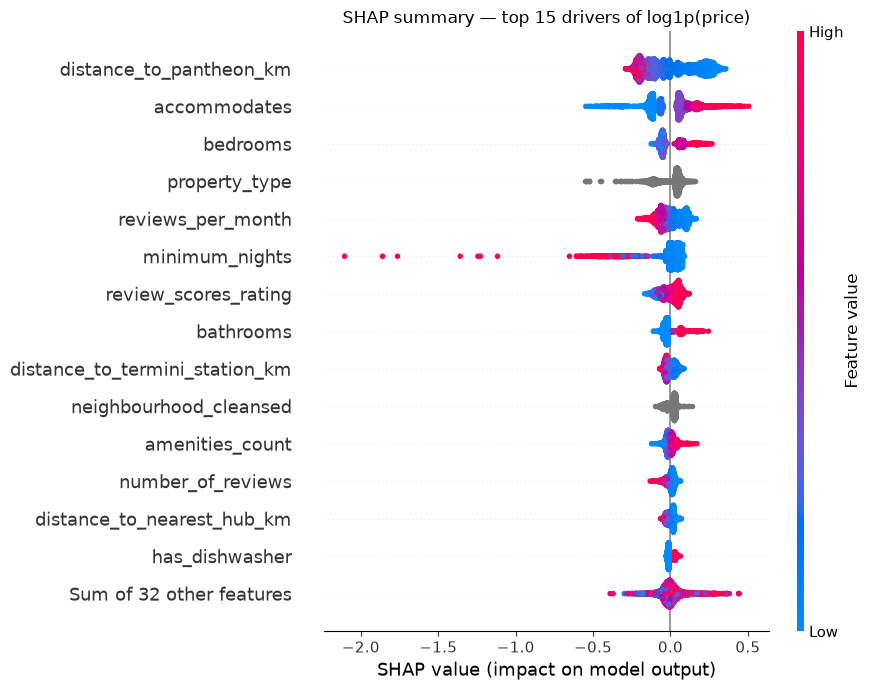

In [6]:
shap.plots.beeswarm(shap_values, max_display=15, show=False)
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.title("SHAP summary — top 15 drivers of log1p(price)")
plt.tight_layout()
plt.show()

## 5. Approximate euro impact of the top drivers

For each of the top 15 features, `mean(|SHAP|)` measures how much it
typically moves the prediction, in log-price units. To make that concrete in
euros, we anchor it at the dataset's median price: "if a typical
(median-priced) listing's value for this feature swung from its low SHAP
impact to its high SHAP impact, price would move by about this many euros."
For binary amenity flags this is the average euro gap between having vs. not
having the amenity, at that median-price anchor.

In [7]:
median_price = float(df["price"].median())
mean_abs_shap = pd.Series(np.abs(shap_values.values).mean(axis=0), index=mt.FEATURE_COLUMNS)
top_features = mean_abs_shap.sort_values(ascending=False).head(15)

rows = []
for feat in top_features.index:
    col_idx = mt.FEATURE_COLUMNS.index(feat)
    vals = shap_values.values[:, col_idx]
    if feat in mt.BOOLEAN_FEATURES:
        raw = X_sample[feat].to_numpy()
        has_it = vals[raw == 1]
        no_it = vals[raw == 0]
        swing = (has_it.mean() if len(has_it) else np.nan) - (no_it.mean() if len(no_it) else np.nan)
        label = "has vs. lacks"
    else:
        swing = np.percentile(vals, 95) - np.percentile(vals, 5)
        label = "5th->95th pct range"

    euro_swing = np.expm1(np.log1p(median_price) + swing) - median_price
    rows.append({"feature": feat, "typical_effect": label, "approx_eur_swing": round(euro_swing, 1)})

impact_table = pd.DataFrame(rows).sort_values("approx_eur_swing", key=np.abs, ascending=False)
impact_table

,feature,typical_effect,approx_eur_swing
0,distance_to_pantheon_km,5th->95th pct range,100.9
1,accommodates,5th->95th pct range,68.6
5,minimum_nights,5th->95th pct range,68.4
2,bedrooms,5th->95th pct range,43.7
4,reviews_per_month,5th->95th pct range,37.8
3,property_type,5th->95th pct range,35.8
6,review_scores_rating,5th->95th pct range,30.5
7,bathrooms,5th->95th pct range,22.3
8,distance_to_termini_station_km,5th->95th pct range,15.3
9,neighbourhood_cleansed,5th->95th pct range,13.9


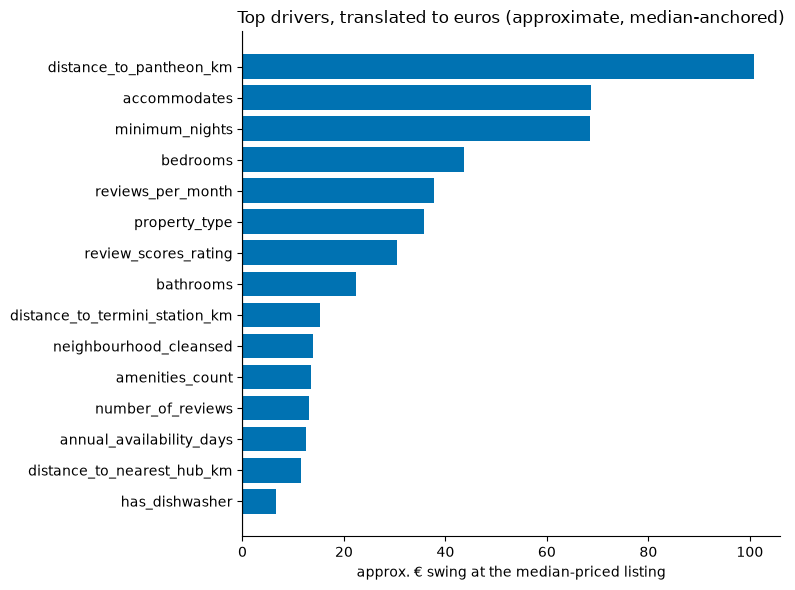

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_df = impact_table.set_index("feature")["approx_eur_swing"].sort_values()
colors = [PALETTE[0] if v >= 0 else PALETTE[3] for v in plot_df.values]
ax.barh(plot_df.index, plot_df.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("approx. \u20ac swing at the median-priced listing")
ax.set_title("Top drivers, translated to euros (approximate, median-anchored)")
fig.tight_layout()
plt.show()

## 6. How steep is the "distance from the Colosseum" discount?

A SHAP dependence plot shows how the model's log-price contribution for
`distance_to_colosseum_km` changes as that distance grows. We fit a simple
linear trend over the bulk of the data (0-5 km, where the vast majority of
listings sit) to translate the slope into an approximate euro-per-kilometre
figure at the median price.

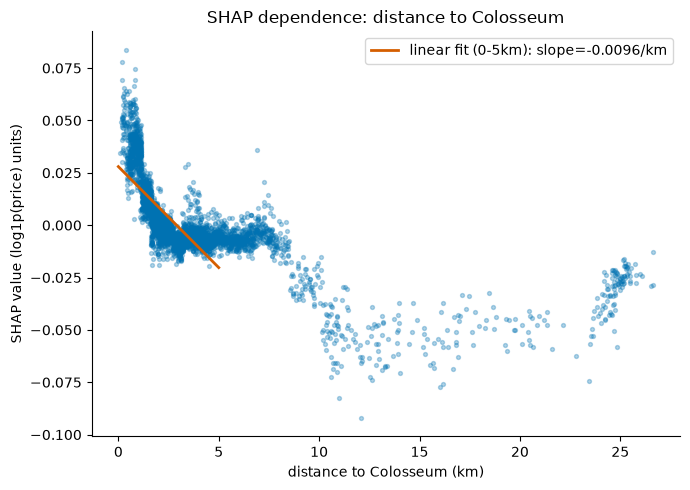

Slope: -0.0096 log1p(price) units per km (over 0-5km).
Approx. at the median listing (€159/night): a discount of €1.54/night per km farther from the Colosseum.


In [9]:
col_idx = mt.FEATURE_COLUMNS.index("distance_to_colosseum_km")
dist_vals = X_sample["distance_to_colosseum_km"].to_numpy()
dist_shap = shap_values.values[:, col_idx]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(dist_vals, dist_shap, s=8, alpha=0.3, color=PALETTE[0])
ax.set_xlabel("distance to Colosseum (km)")
ax.set_ylabel("SHAP value (log1p(price) units)")
ax.set_title("SHAP dependence: distance to Colosseum")

mask = dist_vals <= 5
slope, intercept = np.polyfit(dist_vals[mask], dist_shap[mask], 1)
xs = np.linspace(0, 5, 50)
ax.plot(xs, slope * xs + intercept, color=PALETTE[3], linewidth=2, label=f"linear fit (0-5km): slope={slope:.4f}/km")
ax.legend()
fig.tight_layout()
plt.show()

eur_per_km = np.expm1(np.log1p(median_price) + slope) - median_price
print(f"Slope: {slope:.4f} log1p(price) units per km (over 0-5km).")
print(f"Approx. at the median listing (\u20ac{median_price:.0f}/night): "
      f"{'a discount of' if eur_per_km < 0 else 'a premium of'} \u20ac{abs(eur_per_km):.2f}/night per km "
      f"{'farther from' if eur_per_km < 0 else 'closer to'} the Colosseum.")

## 7. Local explanations: three individual listings

Rather than hand-pick listings by eye, we select them by their **spatial
out-of-fold residual** (`actual - predicted` from Section 2's honest,
held-out CV) — the same signal used for error diagnosis below — so the
"interesting" examples are genuinely ones the model struggled with, not
cherry-picked in-sample. We then explain each one with the SHAP values of
the *final* (100%-data) model, since that's the model being shipped.

- **Most overpriced**: actual price far above what the model expects
  (largest positive residual).
- **Most underpriced "luxury" listing**: among listings the model expects to
  be expensive (top quartile of predicted price), the one priced far below
  that expectation (most negative residual) — an "underpriced penthouse"
  candidate.
- **A well-calibrated listing**: smallest residual near the median price,
  for contrast — what does an explanation look like when the model gets it
  right?

In [10]:
oof_df = df[[
    "price", "neighbourhood_cleansed", "room_type", "property_type", "accommodates",
    "minimum_nights", "maximum_nights",
]].copy()
oof_df["predicted_price"] = oof_pred
oof_df["residual"] = y_dollars_oof - oof_pred  # actual - predicted

overpriced_idx = oof_df["residual"].idxmax()

luxury_mask = oof_df["predicted_price"] >= oof_df["predicted_price"].quantile(0.75)
underpriced_idx = oof_df.loc[luxury_mask, "residual"].idxmin()

near_median = (oof_df["price"] - median_price).abs().sort_values().index[:200]
calibrated_idx = oof_df.loc[near_median, "residual"].abs().idxmin()

examples = {
    "Most overpriced": overpriced_idx,
    "Underpriced luxury listing": underpriced_idx,
    "Well-calibrated listing": calibrated_idx,
}

oof_df.loc[list(examples.values())].assign(label=list(examples.keys())).set_index("label")

,price,neighbourhood_cleansed,room_type,property_type,accommodates,minimum_nights,maximum_nights,predicted_price,residual
label,,,,,,,,,
Most overpriced,554.45,X Ostia/Acilia,Entire home/apt,Entire rental unit,2,29.0,29.0,63.255587,491.194413
Underpriced luxury listing,120.48,I Centro Storico,Entire home/apt,Entire rental unit,9,31.0,365.0,358.311421,-237.831421
Well-calibrated listing,159.00,I Centro Storico,Entire home/apt,Entire rental unit,5,2.0,1125.0,158.905709,0.094291


In [11]:
def dollar_waterfall(row_idx: int, top_n: int = 10) -> pd.DataFrame:
    """Exact euro-by-euro decomposition of one listing's prediction, in the
    same rank order SHAP's own waterfall plot uses (largest |impact| first),
    computed by walking log-space contributions cumulatively and converting
    each running total through expm1 -- exact for THIS listing (unlike the
    median-anchored approximation in Section 5)."""
    row = X_full.iloc[[row_idx]]
    sv = explainer(row)
    base = float(sv.base_values[0])
    vals = sv.values[0]

    order = np.argsort(-np.abs(vals))
    cum_log = base
    price_prev = np.expm1(cum_log)
    steps = [{"feature": "base rate", "value": None, "cumulative_price": round(price_prev, 1), "eur_delta": None}]
    for i in order[:top_n]:
        cum_log += vals[i]
        price_now = np.expm1(cum_log)
        steps.append({
            "feature": mt.FEATURE_COLUMNS[i],
            "value": row.iloc[0, i],
            "cumulative_price": round(price_now, 1),
            "eur_delta": round(price_now - price_prev, 1),
        })
        price_prev = price_now

    remaining_log = base + vals.sum() - cum_log
    if abs(remaining_log) > 1e-9:
        final_price = np.expm1(base + vals.sum())
        steps.append({
            "feature": f"other {len(vals) - top_n} features (combined)",
            "value": None,
            "cumulative_price": round(final_price, 1),
            "eur_delta": round(final_price - price_prev, 1),
        })
    return pd.DataFrame(steps)

Most overpriced  (row 19960)
price                                 554.45
neighbourhood_cleansed        X Ostia/Acilia
room_type                    Entire home/apt
property_type             Entire rental unit
accommodates                               2
minimum_nights                          29.0
maximum_nights                          29.0
predicted_price                    63.255587
residual                          491.194413



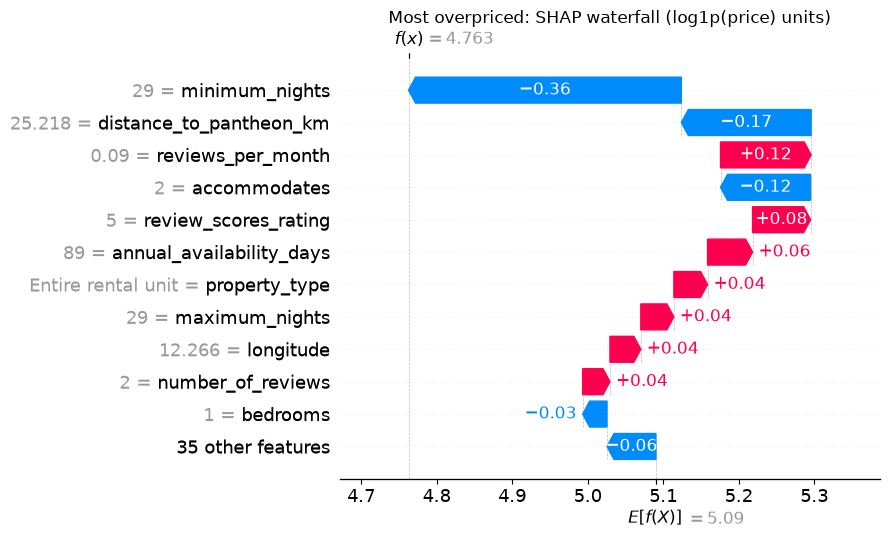

,feature,value,cumulative_price,eur_delta
0,base rate,None,161.4,NaN
1,minimum_nights,29.0,112.2,-49.2
2,distance_to_pantheon_km,25.218,94.3,-17.9
3,reviews_per_month,0.09,106.5,12.2
4,accommodates,2,94.4,-12.1
5,review_scores_rating,5.0,102.0,7.6
6,annual_availability_days,89,108.3,6.3
7,property_type,Entire rental unit,113.3,5.0
8,maximum_nights,29.0,118.4,5.1
9,longitude,12.26593,123.4,5.0


Underpriced luxury listing  (row 16242)
price                                 120.48
neighbourhood_cleansed      I Centro Storico
room_type                    Entire home/apt
property_type             Entire rental unit
accommodates                               9
minimum_nights                          31.0
maximum_nights                         365.0
predicted_price                   358.311421
residual                         -237.831421



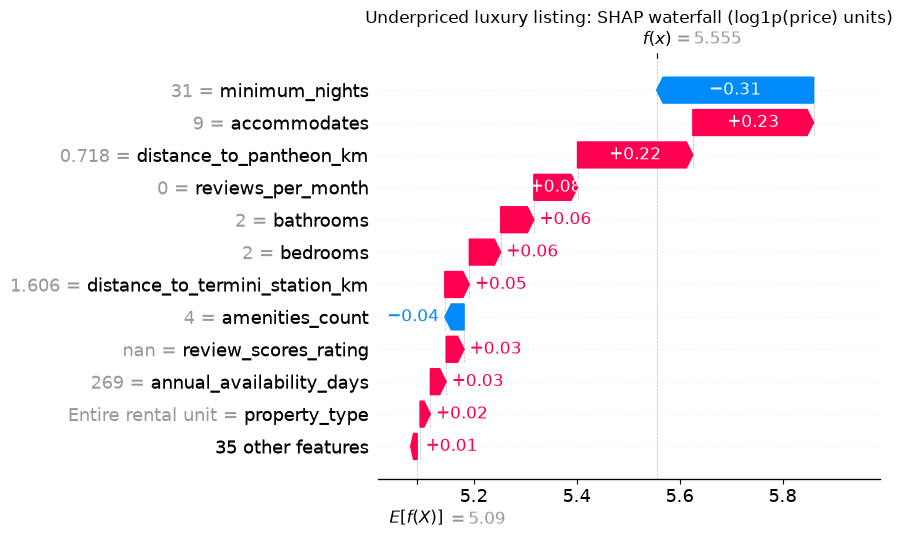

,feature,value,cumulative_price,eur_delta
0,base rate,NaN,161.4,NaN
1,minimum_nights,31.000,118.7,-42.7
2,accommodates,9.000,150.4,31.7
3,distance_to_pantheon_km,0.718,188.4,38.0
4,reviews_per_month,0.000,205.2,16.8
5,bathrooms,2.000,218.9,13.7
6,bedrooms,2.000,232.7,13.8
7,distance_to_termini_station_km,1.606,244.1,11.4
8,amenities_count,4.000,235.1,-9.0
9,review_scores_rating,NaN,243.5,8.4


Well-calibrated listing  (row 32344)
price                                  159.0
neighbourhood_cleansed      I Centro Storico
room_type                    Entire home/apt
property_type             Entire rental unit
accommodates                               5
minimum_nights                           2.0
maximum_nights                        1125.0
predicted_price                   158.905709
residual                            0.094291



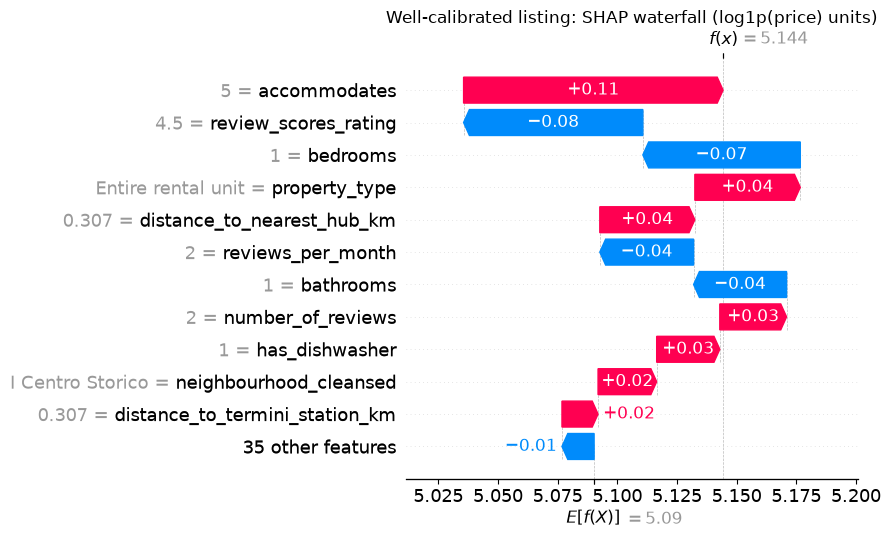

,feature,value,cumulative_price,eur_delta
0,base rate,None,161.4,NaN
1,accommodates,5,180.1,18.7
2,review_scores_rating,4.5,167.0,-13.1
3,bedrooms,1.0,156.3,-10.7
4,property_type,Entire rental unit,163.4,7.1
5,distance_to_nearest_hub_km,0.307,170.0,6.7
6,reviews_per_month,2.0,163.5,-6.6
7,bathrooms,1.0,157.2,-6.3
8,number_of_reviews,2,161.7,4.5
9,has_dishwasher,1.0,166.0,4.4


In [12]:
for label, idx in examples.items():
    row = X_full.iloc[[idx]]
    sv = explainer(row)

    print("=" * 90)
    print(f"{label}  (row {idx})")
    print(oof_df.loc[idx].to_string())
    print()

    shap.plots.waterfall(sv[0], max_display=12, show=False)
    fig = plt.gcf()
    fig.set_size_inches(9, 5.5)
    plt.title(f"{label}: SHAP waterfall (log1p(price) units)")
    plt.tight_layout()
    plt.show()

    display(dollar_waterfall(idx))

**A data-quality flag worth calling out**: check the `minimum_nights` /
`maximum_nights` columns on the "most overpriced" example above. A listing
with `minimum_nights == maximum_nights` (a fixed, long-stay-only booking —
e.g. exactly 29 nights) is a strong sign that its `price` field is *not* a
typical nightly tourist rate; Airbnb's own pricing UI sometimes surfaces a
long-stay-adjusted or monthly-derived nightly figure for these. The model
isn't "wrong" here so much as being asked to predict a short-stay-style
nightly price for a listing that isn't really sold that way — a labeling
artifact from Phase 1, not a modeling failure. Worth a `minimum_nights`-aware
segment or an explicit "long-stay listing" flag in a future iteration.

## 8. Error diagnosis (not a fix — a diagnosis)

Using the spatial out-of-fold predictions from Section 2 (genuine held-out
error, never in-sample).

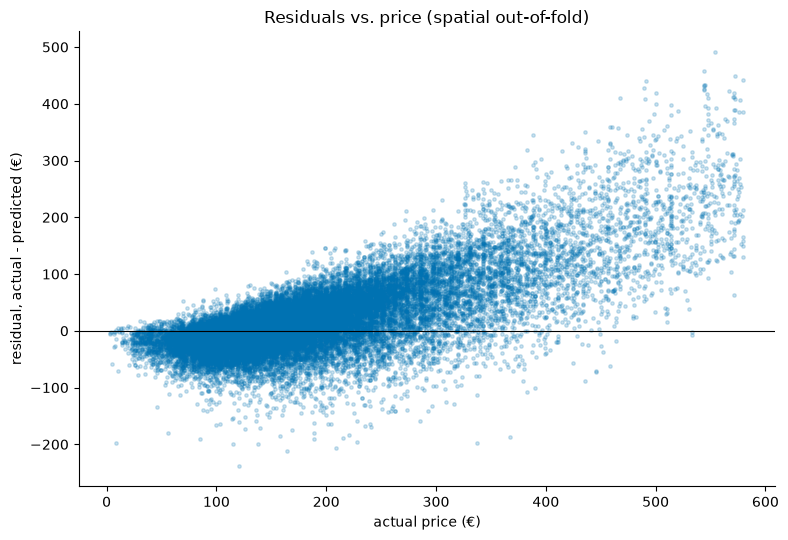

In [13]:
residuals = y_dollars_oof - oof_pred

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(y_dollars_oof, residuals, s=6, alpha=0.2, color=PALETTE[0])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("actual price (\u20ac)")
ax.set_ylabel("residual, actual - predicted (\u20ac)")
ax.set_title("Residuals vs. price (spatial out-of-fold)")
fig.tight_layout()
plt.show()

The spread of residuals visibly widens as price increases — classic
heteroscedasticity. Binning by price band makes it concrete: absolute error
grows sharply in the luxury tail (€500+), even though *relative* error
(MdAPE) tends to compress at the high end, since these listings often carry
premiums (view, historic character, exclusivity) that aren't captured by the
structured feature set.

In [14]:
price_bins = [0, 100, 200, 300, 500, np.inf]
bin_labels = ["<\u20ac100", "\u20ac100-200", "\u20ac200-300", "\u20ac300-500", "\u20ac500+"]
band = pd.cut(y_dollars_oof, bins=price_bins, labels=bin_labels)

band_df = pd.DataFrame({"price": y_dollars_oof, "pred": oof_pred, "band": band})
band_stats = band_df.groupby("band", observed=True).apply(
    lambda g: pd.Series({
        "n": len(g),
        "MAE": np.mean(np.abs(g["price"] - g["pred"])),
        "MdAPE_pct": np.median(np.abs(g["price"] - g["pred"]) / g["price"]) * 100,
    }),
    include_groups=False,
)
band_stats

,n,MAE,MdAPE_pct
band,,,
<€100,5127.0,22.878250,23.755515
€100-200,17466.0,24.060520,13.110713
€200-300,6686.0,51.442144,19.692135
€300-500,3348.0,114.005093,29.003753
€500+,430.0,223.778354,40.510313


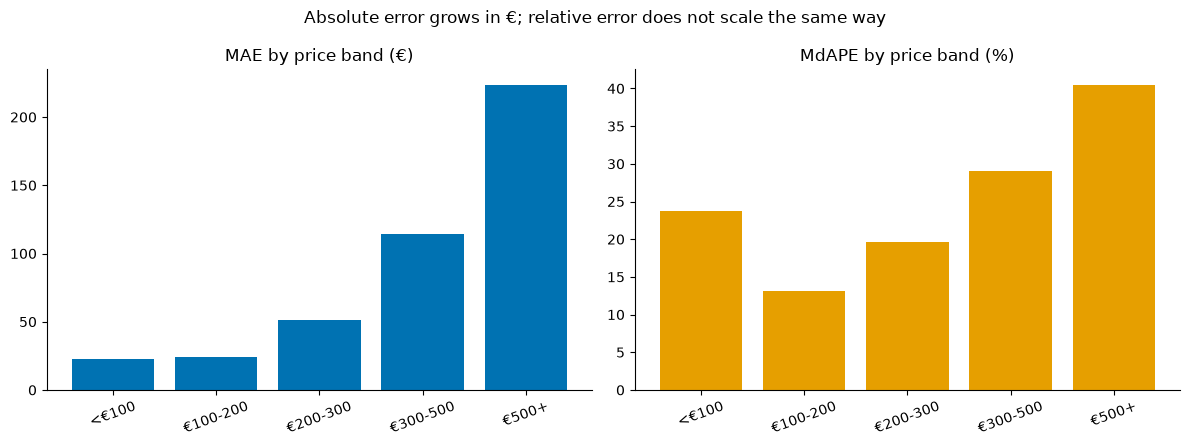

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(band_stats.index.astype(str), band_stats["MAE"], color=PALETTE[0])
axes[0].set_title("MAE by price band (\u20ac)")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(band_stats.index.astype(str), band_stats["MdAPE_pct"], color=PALETTE[1])
axes[1].set_title("MdAPE by price band (%)")
axes[1].tick_params(axis="x", rotation=20)

fig.suptitle("Absolute error grows in \u20ac; relative error does not scale the same way")
fig.tight_layout()
plt.show()

### MAE per neighbourhood: is the historic centre worse?

In [16]:
neigh_df = pd.DataFrame({
    "neighbourhood": df["neighbourhood_cleansed"].to_numpy(),
    "price": y_dollars_oof,
    "pred": oof_pred,
})
neigh_stats = neigh_df.groupby("neighbourhood", observed=True).apply(
    lambda g: pd.Series({
        "n": len(g),
        "median_price": g["price"].median(),
        "MAE": np.mean(np.abs(g["price"] - g["pred"])),
        "MdAPE_pct": np.median(np.abs(g["price"] - g["pred"]) / g["price"]) * 100,
    }),
    include_groups=False,
).sort_values("MAE", ascending=False)
neigh_stats.round(1)

,n,median_price,MAE,MdAPE_pct
neighbourhood,,,,
I Centro Storico,16649.0,194.0,49.4,17.5
XV Cassia/Flaminia,508.0,129.4,41.6,20.6
II Parioli/Nomentano,2216.0,148.4,37.4,16.9
X Ostia/Acilia,892.0,128.0,37.4,20.1
IX Eur,355.0,119.8,36.7,19.2
XIII Aurelia,2391.0,152.0,35.3,15.9
XIV Monte Mario,711.0,126.7,34.9,16.8
VI Roma delle Torri,292.0,102.0,31.1,19.7
XII Monte Verde,1806.0,139.0,31.0,16.5


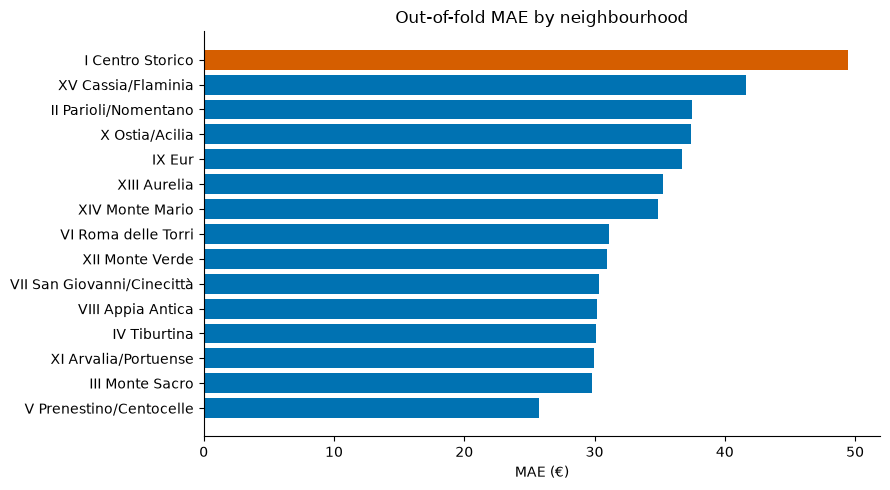

I Centro Storico MAE: €49.4  |  mean of other neighbourhoods: €33.0  (+50%)


In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = [PALETTE[3] if n == "I Centro Storico" else PALETTE[0] for n in neigh_stats.index]
ax.barh(neigh_stats.index[::-1], neigh_stats["MAE"].values[::-1], color=colors[::-1])
ax.set_xlabel("MAE (\u20ac)")
ax.set_title("Out-of-fold MAE by neighbourhood")
fig.tight_layout()
plt.show()

centro_mae = neigh_stats.loc["I Centro Storico", "MAE"]
other_mae = neigh_stats.drop("I Centro Storico")["MAE"].mean()
print(f"I Centro Storico MAE: \u20ac{centro_mae:.1f}  |  mean of other neighbourhoods: \u20ac{other_mae:.1f}"
      f"  ({centro_mae / other_mae - 1:+.0%})")

## Findings & write-up

**The model's two clearest failure modes:**

1. **The luxury tail (€500+/night).** Absolute error (MAE, RMSE) grows
   sharply with price, well beyond what relative error (MdAPE) alone would
   suggest. A handful of villas, palazzos, and penthouses command prices
   driven by attributes we don't have structured data for — interior finish
   quality, specific views, brand/design pedigree, event-hosting capacity —
   so the model falls back on its closest structured proxies (accommodates,
   bedrooms, borough) and under- or over-shoots. This is expected: no
   amount of hyperparameter tuning fixes a *missing-feature* problem.

2. **I Centro Storico has the highest absolute error of any neighbourhood**,
   consistent with it being both the largest group (~50% of listings) *and*
   the most heterogeneous: it mixes tiny tourist studios, mid-range
   apartments, and multi-million-euro historic palazzos within meters of
   each other, so "distance to the Pantheon" and "borough = Centro Storico"
   carry much less price signal there than the same features do in more
   architecturally uniform outer districts. In relative terms (MdAPE) the
   gap is smaller than in absolute terms, because Centro Storico's median
   price is also the highest — but the euro-denominated miss is real, and
   it's the neighbourhood most likely to drive a bad pricing recommendation
   in absolute terms.

3. **Long-stay listings mislabeled as nightly-priced.** The single largest
   residual in the dataset turned out to be a `minimum_nights == max_nights
   == 29` listing — a monthly-only booking where the nightly `price` field
   likely isn't a genuine short-stay rate. That's a Phase 1 data-hygiene gap
   (the outlier filter operated on the *global* price distribution, not
   conditioned on stay length), not something a better model can fix.

**What this does *not* mean**: none of these findings is a bug to patch with
more boosting rounds. Two are a ceiling set by the feature set, and one is a
labeling artifact upstream of modeling entirely. The honest next steps would
be: adding unstructured signal (listing description embeddings, photo-based
quality scores) or explicit interior/renovation-quality fields for the
luxury-tail and Centro Storico gaps, and a minimum-nights-aware filter or
segment for the long-stay artifact — not more spatial or CV engineering on
the current inputs.

## Deployment note

The fitted pipeline is saved at **`models/lightgbm_price_model.joblib`**,
alongside its feature contract at `models/lightgbm_feature_spec.json`. To
reuse it:

```python
import model_training as mt

model = mt.load_model("models/lightgbm_price_model.joblib")
X, _, _ = mt.prepare_native_features(new_listings_df)  # same category dtypes as training
price_pred = np.expm1(model.predict(X))
```

## 9. Export artifacts for the Phase 5 dashboard

Persist the out-of-fold predictions (with their segment labels) so the
Streamlit dashboard can shade the choropleth by prediction error and build
bootstrapped scenario price distributions without re-running 5-fold CV on
every page load.

In [18]:
dashboard_oof = oof_df.copy()
dashboard_oof["residual_ratio"] = np.where(
    dashboard_oof["predicted_price"] > 0,
    dashboard_oof["price"] / dashboard_oof["predicted_price"],
    np.nan,
)

oof_export_path = PROJECT_ROOT / "data" / "processed" / "oof_predictions.parquet"
dashboard_oof.to_parquet(oof_export_path, index=False)
print(f"Saved {len(dashboard_oof):,} rows to {oof_export_path}")
dashboard_oof.head()

Saved 33,057 rows to /home/matthew/code/notebooks/personal/airbnb_rome/data/processed/oof_predictions.parquet


,price,neighbourhood_cleansed,room_type,property_type,accommodates,minimum_nights,maximum_nights,predicted_price,residual,residual_ratio
0,59.52,VIII Appia Antica,Private room,Private room,1,31.0,1125.0,61.836627,-2.316627,0.962536
1,117.13,II Parioli/Nomentano,Entire home/apt,Entire rental unit,3,31.0,365.0,114.219984,2.910016,1.025477
2,160.60,I Centro Storico,Entire home/apt,Entire condo,5,2.0,1125.0,165.986115,-5.386115,0.967551
3,243.67,I Centro Storico,Entire home/apt,Entire vacation home,4,3.0,365.0,141.998229,101.671771,1.716007
4,302.50,I Centro Storico,Entire home/apt,Entire vacation home,4,2.0,365.0,181.275317,121.224683,1.668732
